<a href="https://colab.research.google.com/github/LucioFassarella/SSD---Simulacoes-de-Sistemas-Dissipativos/blob/main/SQSD_Modelo_qubit_fase-amortecida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red"><b>Simulação Quântica de Sistemas Dissipativos</b></font>

<div align="center"><font color="magenta"><b>Qubit com amortecimento de fase</b></font></div>
<!--
<center><img align = "center" src="https://drive.google.com/uc?export=view&id=1usXrPscUXzfQF5wNtkvuVGARuuhcgyw-" alt="grafo" width="500"></center>

<center>"You never understand things. You just get used to them." (John von Neumann)</center>
-->

---
**Referências**

*   Daniel A. Lidar: *Lecture Notes on the Theory of Open Quantum Systems*. URL:
[https://arxiv.org/abs/1902.00967](https://arxiv.org/abs/1902.00967).
    *   (Lindbladian -> Kraus Operators: pp.47-48)
*   Pirandola, Stefano *et al.*: *Minimal qudit code for a qubit in the phase-damping channel*. Physical Review A 77, 032309 (2008). URL: [https://www-users.york.ac.uk/~sb54/papers/pmbv08.pdf](https://www-users.york.ac.uk/~sb54/papers/pmbv08.pdf).

*   Kline, S.J.: *Amplitude Damping vs Phase Damping in Quantum Computing: Key Differences and Impacts on Qubit Fidelity*. URL: [https://techiny.com/quantum-computing/amplitude-damping-vs-phase-damping](https://techiny.com/quantum-computing/amplitude-damping-vs-phase-damping).

*   Bohrium: *Amplitude Damping and Phase Damping Channels*. URL: [https://www.bohrium.com/en/sciencepedia/feynman/quantum_information_quantum_computation-amplitude_damping_and_phase_damping_channels](https://www.bohrium.com/en/sciencepedia/feynman/quantum_information_quantum_computation-amplitude_damping_and_phase_damping_channels).

Qiskit
*   [Método qiskit.quantum_info.Choi](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Choi)



**Espaço de Hilbert e equação de Lindblad**:
$$
\mathcal{H} = \mathcal{Q}_1
$$
$$
\frac{d}{dt}\rho = -i[\omega Z,\rho] + \gamma(Z\rho Z - \rho).
$$

**Hamiltoniano e operador de Lindblad**:
$$
H =  \omega Z
$$
$$
L_1 := Z,\ L_0 = - \frac{\gamma}{2} I - i\omega Z.
$$
<!--
Operadores de Kraus infinitezimais com operador residual $R$::
$$
K_0 = I + L_0dt + Rdt^2,\ \ %
K_1 = \sqrt{\gamma dt}Z;
$$
Equação residual:
$$
	\begin{split}
		(\frac{\gamma^2}{4} + \omega^2) I + R + R^\dagger + (- \frac{\gamma}{2}( R + R^\dagger) - i[\omega Z,R] )dt + R^\dagger R dt^2 = 0.
	\end{split}
$$
Com o ansatz $R = r I\ (r \in \mathbb{R})$, essa equação se reduz à seguinte equação quadrática para $r$:
$$
dt^2r^2 + (2 -\gamma dt) r + (\frac{\gamma^2}{4} + \omega^2)   = 0,
$$
cuja solução é:
$$
r = - \frac{1 - \gamma dt/2 \pm \sqrt{1- \gamma dt - \omega^2 dt^2}}{dt^2}.
$$
Para $|dt| \neq 0$ suficientemente pequeno, o discriminante será positivo e teremos soluções reais para o parâmetro $r$.
-->

**Unitário de Stinespring**:

⚛
$$
W = |0\rangle\langle 0|\otimes U(\theta, -\zeta, +\zeta) + |1\rangle\langle 1|\otimes U(\theta,\zeta+\pi,-\zeta),
$$

onde:

⚛
$$
dt > 0;
$$
⚛
$$
\begin{split}
\kappa_0 &:= 1 - \frac{\gamma}{2}dt + rdt^2\\
\kappa_1 &:= -\omega dt.
\end{split}
$$
⚛
$$
\begin{split}
	\theta &= 2 \arctan\left(\sqrt{\frac{\gamma dt}{\kappa_0^2 + \kappa_1^2}}\right) \in \left(0,\frac{\pi}{2}\right);\\
	\zeta &= \arg(\kappa_0 + i\kappa_1) = \arctan\left(\frac{\kappa_1}{\kappa_0}\right) \in \left(-\frac{\pi}{2},\frac{\pi}{2}\right);\\
	r &= -\frac{1 - \gamma dt/2 \pm \sqrt{1 - \gamma dt - \omega^2 dt^2}}{dt^2}.
\end{split}
$$


## QISKIT: Carregamento

In [1]:
!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib
!pip install pylatexenc

import qiskit
qiskit.__version__

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 33.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/

'2.5.1'

In [2]:
'''
from qiskit_ibm_runtime import QiskitRuntimeService

# Conecção com a IBM

token_privado = "" # <-- Inserir token privado na IBM
instance_do_projeto = "" # <-- Inserir instance do projeto

from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token = token_privado,
    instance = instance_do_projeto
    )

## Save account to disk and save it as the default.
#QiskitRuntimeService.save_account(channel="ibm_cloud", token="<IBM Cloud API key>", instance="<IBM Cloud CRN>", name="account-name", set_as_default=True)

## Load the saved credentials
#service = QiskitRuntimeService(name="account-name")
'''

'\nfrom qiskit_ibm_runtime import QiskitRuntimeService\n\n# Conecção com a IBM\n\ntoken_privado = "" # <-- Inserir token privado na IBM\ninstance_do_projeto = "" # <-- Inserir instance do projeto\n\nfrom qiskit_ibm_runtime import QiskitRuntimeService\nservice = QiskitRuntimeService(\n    channel="ibm_cloud",\n    token = token_privado,\n    instance = instance_do_projeto\n    )\n\n## Save account to disk and save it as the default.\n#QiskitRuntimeService.save_account(channel="ibm_cloud", token="<IBM Cloud API key>", instance="<IBM Cloud CRN>", name="account-name", set_as_default=True)\n\n## Load the saved credentials\n#service = QiskitRuntimeService(name="account-name")\n'

In [3]:
# Qiskit: métodos básicos

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

from qiskit import transpile

from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city

# Modelagem

In [5]:
"PARÂMETROS DO SISTEMA e da SIMULAÇÃO"

import numpy as np

# Parâmetros do sistema

w = 1.2 # Hamiltoniano
print(f"Parâmetro do Hamiltoniano: w = {w}")

g = 1 # taxa de dissipação
print(f"Taxa de dissipação: g = {g}")

# Parâmetros da simulação

tempo = 1 # duração da simulação
print(f"Tempo de simulação: tempo = {tempo}")

num_steps = 10 # número de passos da simulação
print(f"Número de passos da simulação: num_steps = {num_steps}")

dt = tempo/num_steps # step_size = magnitude de ada passo da simulação
print(f"Magnitude dos passos da simulação: dt = {dt}")

r = - (1.-g*dt/2 - np.sqrt(1. - g*dt - w**2*dt**2))/dt**2
print(f"Parâmetro r = {r}")

k0 = 1. - g*dt/2 + r*dt**2
print(f"Parâmetro k0 = {k0}")

k1 = -w*dt
print(f"Parâmetro k1 = {k1}")

theta = 2*np.arctan(np.sqrt(g*dt/(k0**2 + k1**2)))
print(f"Parâmetro theta = {theta}")

zeta = np.arctan(k1/k0)
print(f"Parâmetro zeta = {zeta}")

Parâmetro do Hamiltoniano: w = 1.2
Taxa de dissipação: g = 1
Tempo de simulação: tempo = 1
Número de passos da simulação: num_steps = 10
Magnitude dos passos da simulação: dt = 0.1
Parâmetro r = -0.8936771518512574
Parâmetro k0 = 0.9410632284814874
Parâmetro k1 = -0.12
Parâmetro theta = 0.6435011087932844
Parâmetro zeta = -0.1268308680377276


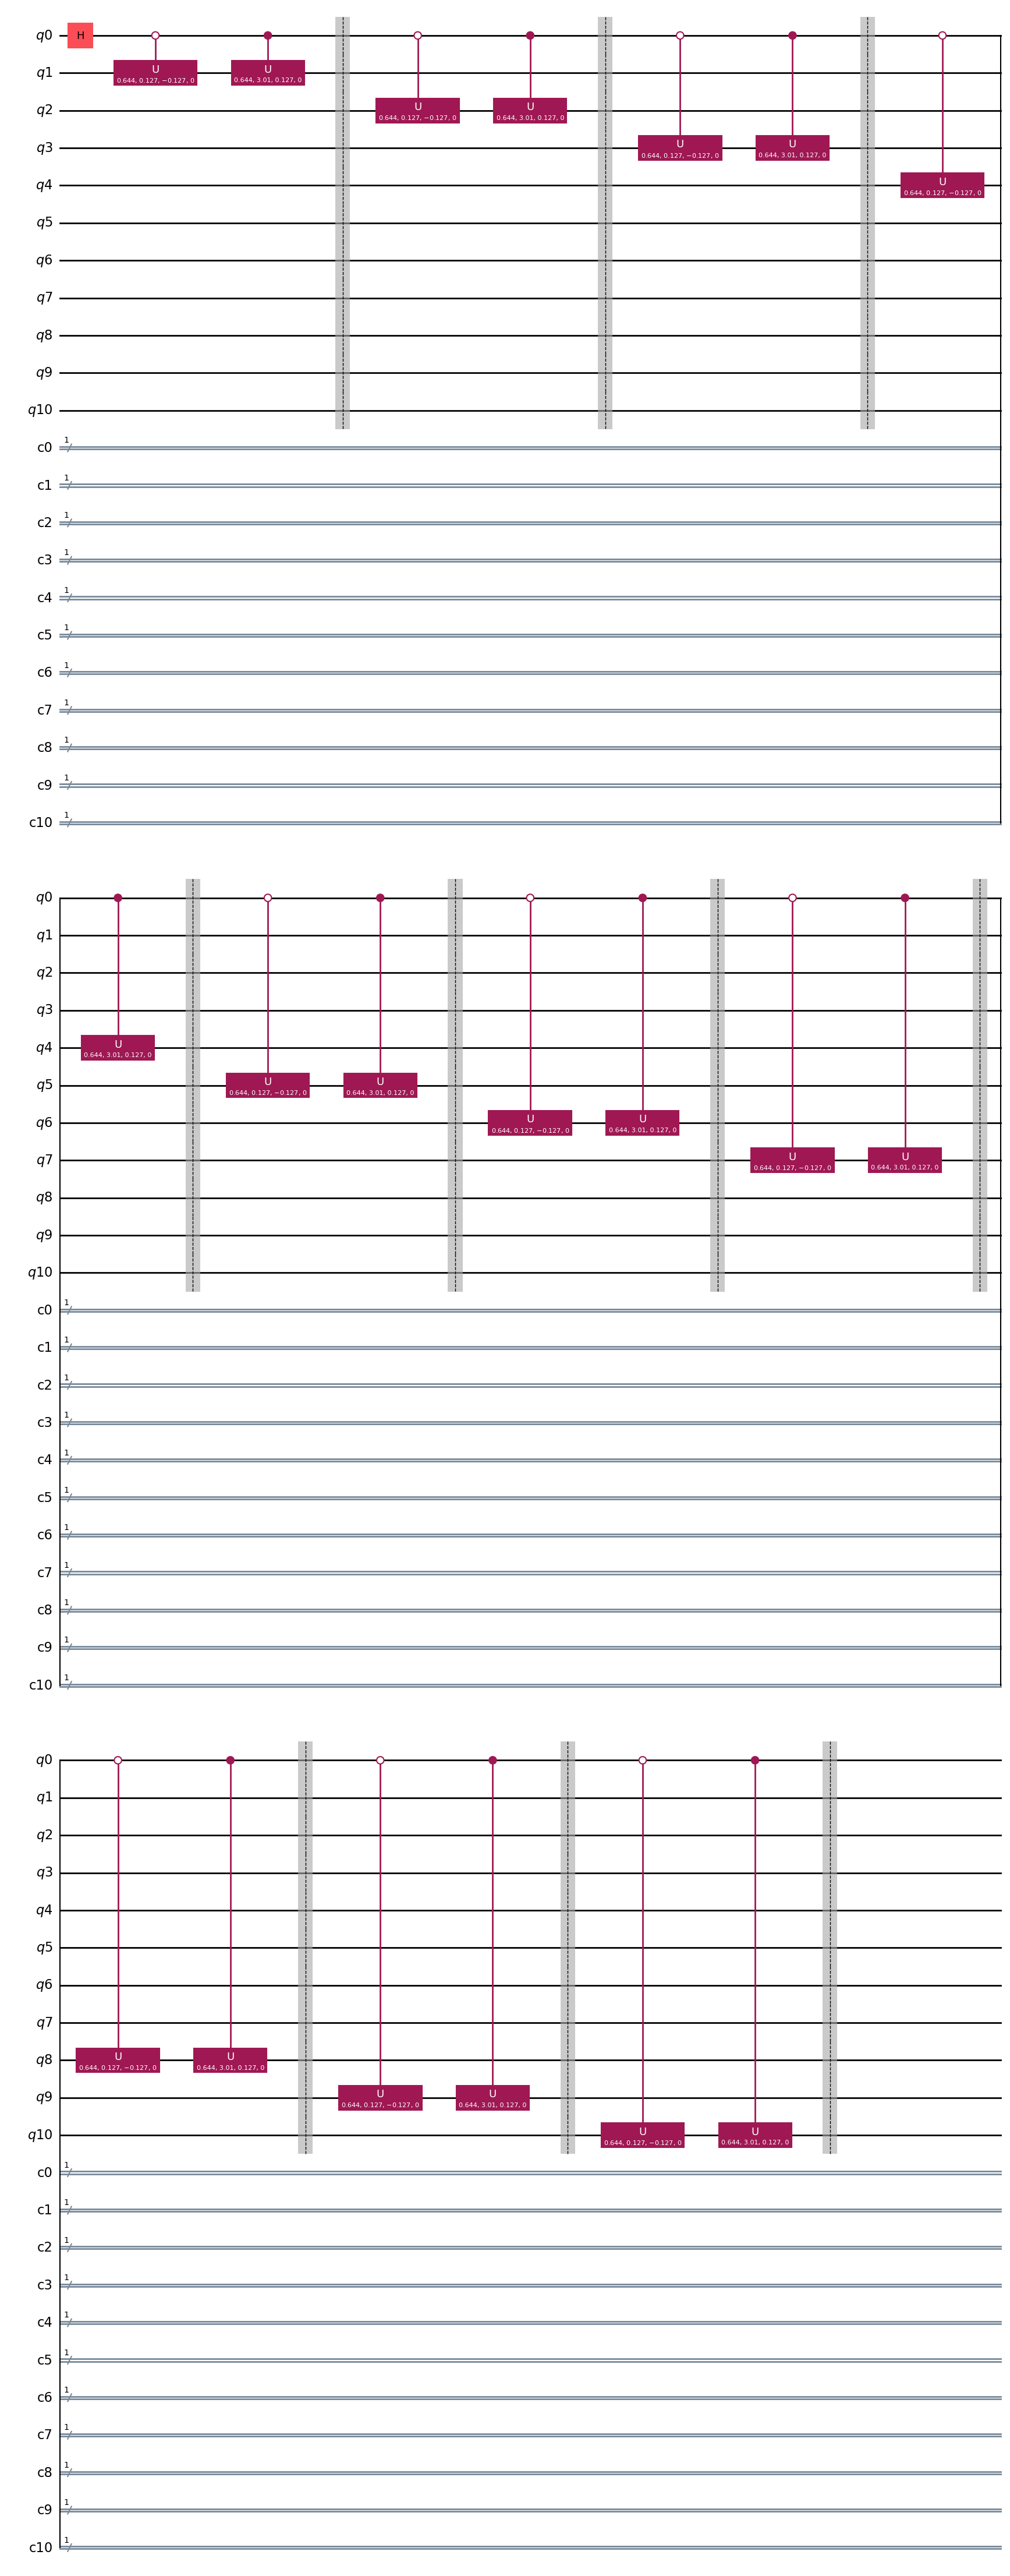

In [6]:
"CIRCUITO QUÂNTICO DA SIMULAÇÃO"

num_qubts = 1 + num_steps # número de qubits do circuito quântico

qbt_system = QuantumRegister(1)  # registro quântico do sistema
qbt_clock = [QuantumRegister(1) for step in range(num_steps)] # registros para evolução temporal

cbt_system = ClassicalRegister(1) # registro clássico do sistema
cbt_clock = [ClassicalRegister(1) for step in range(num_steps)] # registros para medição temporal

qcirc = QuantumCircuit(qbt_system, *qbt_clock, cbt_system, *cbt_clock) # circuito quântico da simulação

#qc_simulacao.draw()

"ESTADO INICIAL"

qcirc.h(qbt_system[0])

"HAMILTONIANO"

# Hamiltoniano
from qiskit.quantum_info import SparsePauliOp

Hamiltoniano = SparsePauliOp.from_sparse_list([("Z", [0], w)], num_qubits= num_qubts) # Hamiltoniano

"UNITÁRIO DE STINESPRING"

from qiskit.circuit.library import UGate

W0_gate = UGate(theta, -zeta, zeta)
CW0_gate = W0_gate.control(1, ctrl_state = "0")

W1_gate = UGate(theta, zeta + np.pi, -zeta)
CW1_gate = W1_gate.control(1, ctrl_state = "1")

for step in range(num_steps):
    qcirc.append(CW0_gate, [qbt_system[0], qbt_clock[step][0]])
    qcirc.append(CW1_gate, [qbt_system[0], qbt_clock[step][0]])
    qcirc.barrier()

qcirc.draw('mpl')


In [ ]:
"EXPERIMENTOS"


In [7]:
from qiskit.quantum_info import Statevector

vetor_estado = Statevector(qcirc)

vetor_estado.draw('latex')

<IPython.core.display.Latex object>

In [8]:
from qiskit_aer.primitives import Estimator as AerEstimator

# Remoção de medidas no circuito para executar o AerEstimator
qcirc_expval = qcirc.remove_final_measurements(inplace=False)

# Inicialização do Estimator
estimator = AerEstimator()

# Execução dos experimentos
job = estimator.run(qcirc_expval, Hamiltoniano)
result = job.result()

# Extração do valor esperado do Hamiltoniano
expectation_value = result.values[0]

print(f"<H>: {expectation_value}")

<H>: 0.014062499999999999
